<a href="https://colab.research.google.com/github/SaisriKumar/Kumar/blob/main/SaiKumar_Palaparti_CPDA_Batch2_EDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Assignment
## By SaiKumar_Palaparti_Batch2

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


## Q1: Data Cleaning
**i. Count and handle missing values.**

In [5]:
print("Missing values before handling:")
print(df.isnull().sum())
# Handling missing values
df = df.dropna()  # or we can fill with mean/median for numericals, mode for categorical
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

Missing values after handling:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Shi

In [4]:
df = pd.read_csv('/content/superstore.csv')
print("Dataset loaded successfully. First 5 rows:")
display(df.head())

Dataset loaded successfully. First 5 rows:


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


**ii. Deal with Duplicate values**

In [ ]:

print("Duplicated rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicated rows after:", df.duplicated().sum())


**iii. Delete unknown columns if present.**

In [6]:

if '记录数' in df.columns:
    df = df.drop(columns=['记录数'])
    print("'记录数' column dropped.")
if 'Market2' in df.columns:
    df = df.drop(columns=['Market2'])
    print("'Market2' column dropped.")


'记录数' column dropped.
'Market2' column dropped.


**iv. Check shape, size, and datatypes of the dataset features.**

In [7]:

print("Shape of dataset:", df.shape)
print("Size of dataset (total elements):", df.size)
print("\nDatatypes:\n", df.dtypes)


Shape of dataset: (51282, 25)
Size of dataset (total elements): 1282050

Datatypes:
 Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
weeknum             int64
dtype: object


## Q2: Perform Univariate Analysis across all numerical features

Numerical Columns: ['Discount', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost', 'Year', 'weeknum']


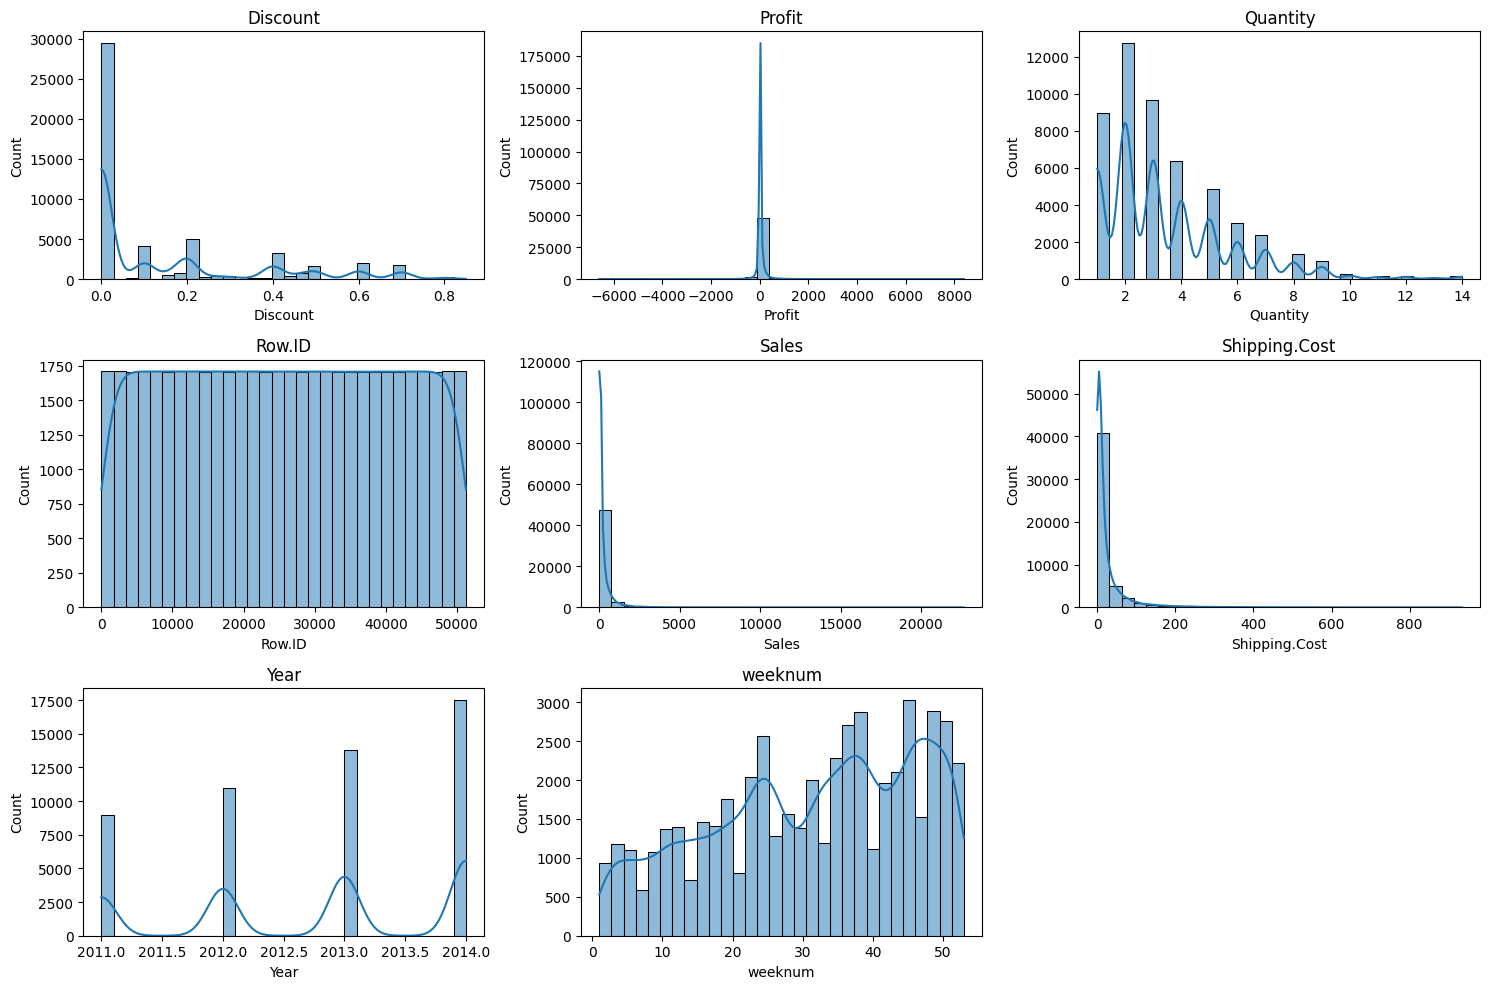

In [8]:

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'row_id' in numerical_cols:
    numerical_cols.remove('row_id')
print("Numerical Columns:", numerical_cols)

# Plot histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


**i. Which features seem useless in the analysis? Explain why?**
`row_id` seems useless because it's just a unique identifier for each row and carries no analytical value.

**ii. Which features are uniformly distributed or normally distributed?**
From histograms, `quantity` appears slightly right-skewed and discrete. None of the columns look perfectly uniform or normally distributed. `weeknum` might be uniformly distributed if sales are steady across the year.

**iii. Which features are right-skewed/left-skewed? What does this signify?**
`sales`, `profit`, `discount`, and `shipping_cost` are heavily right-skewed. This signifies that most orders have small values, but a few orders have extremely high sales/profit/shipping costs.

**iv. Which features have a high number of outliers, and discuss the impact.**

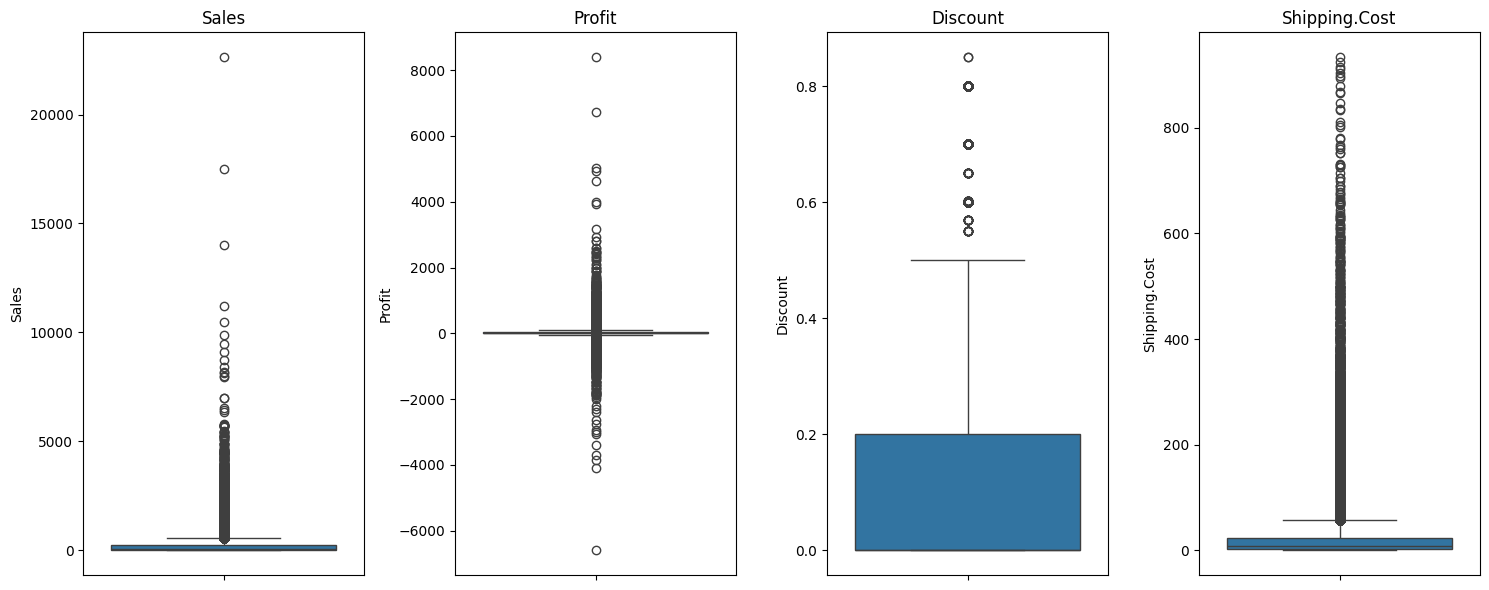

In [9]:

plt.figure(figsize=(15, 6))
for i, col in enumerate(['Sales', 'Profit', 'Discount', 'Shipping.Cost'], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


`sales`, `profit`, and `shipping_cost` have a high number of outliers (large extreme values). This can skew averages (mean) and affect regression models if not handled.

## Q3: Perform Univariate Analysis across all categorical features.

In [10]:

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", cat_cols)


Categorical Columns: ['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Region', 'Segment', 'Ship.Date', 'Ship.Mode', 'State', 'Sub.Category']


**i. Which features seem inaccurate and are not useful as categorical “insights” directly?**
Unique identifiers like `customer_id`, `customer_name`, `order_id`, and `product_name` have too many unique values to provide immediate aggregate categorical insights.

**ii. What’s the issue with treating Customer Name as a categorical feature for modeling?**
High cardinality. Too many unique categories will lead to high dimensionality (e.g., using one-hot encoding), slow down the model, and lead to overfitting.

**iii. Is the Category distribution balanced or skewed? Give a 1-line reason.**

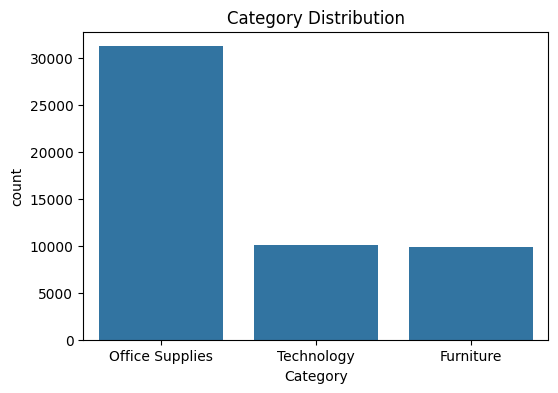

In [11]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Category')
plt.title('Category Distribution')
plt.show()


The category distribution is somewhat balanced but 'Office Supplies' dominate, meaning it's slightly skewed towards daily supplies.

**iv. In Country, does one country dominate strongly? What does that imply about geographic bias?**

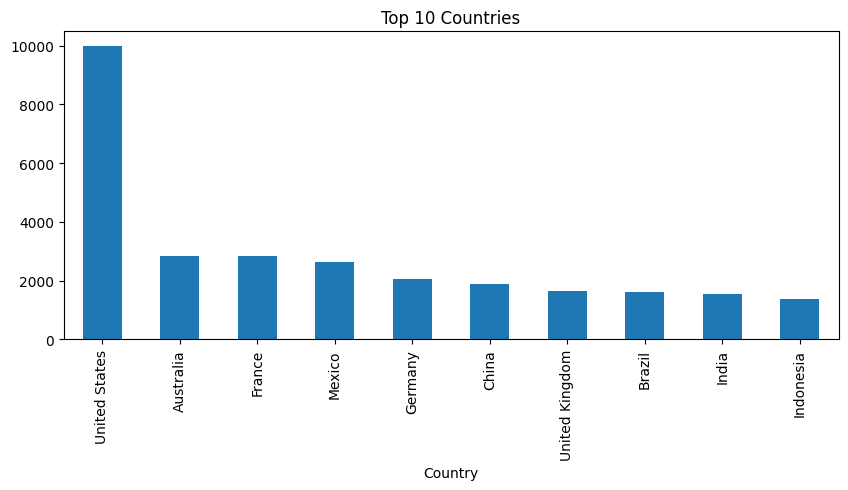

Top 1 country: United States


In [12]:

plt.figure(figsize=(10,4))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.show()
print("Top 1 country:", df['Country'].value_counts().index[0])


Yes, the United States dominates strongly. This implies our analysis and any model trained on this will have geographic bias towards the US market.

**v. Is the City dataset concentrated in a few cities or spread out?**

In [13]:

print("Number of unique cities:", df['City'].nunique())
city_counts = df['City'].value_counts()
print(city_counts.head(10))


Number of unique cities: 3636
City
New York City    914
Los Angeles      747
Philadelphia     537
San Francisco    509
Santo Domingo    443
Manila           432
Seattle          424
Houston          377
Tegucigalpa      362
Jakarta          337
Name: count, dtype: int64


It is spread out across thousands of cities, but highly concentrated in a few top cities like New York, Los Angeles, etc.

## Q4: Perform Bivariant Analysis for numerical-to-numerical features:

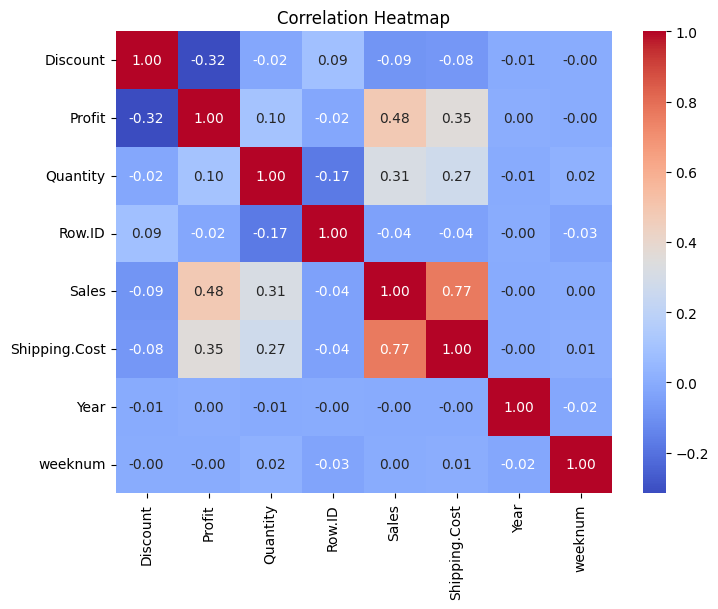

In [14]:

plt.figure(figsize=(8,6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**i. Which two features are most strongly correlated?**
`sales` and `shipping_cost` are highly positively correlated.

**ii. Also name features that are negatively correlated.**
`discount` and `profit` are negatively correlated.

**iii. If your goal is to understand profit, which are the most useful next bivariate checks?**

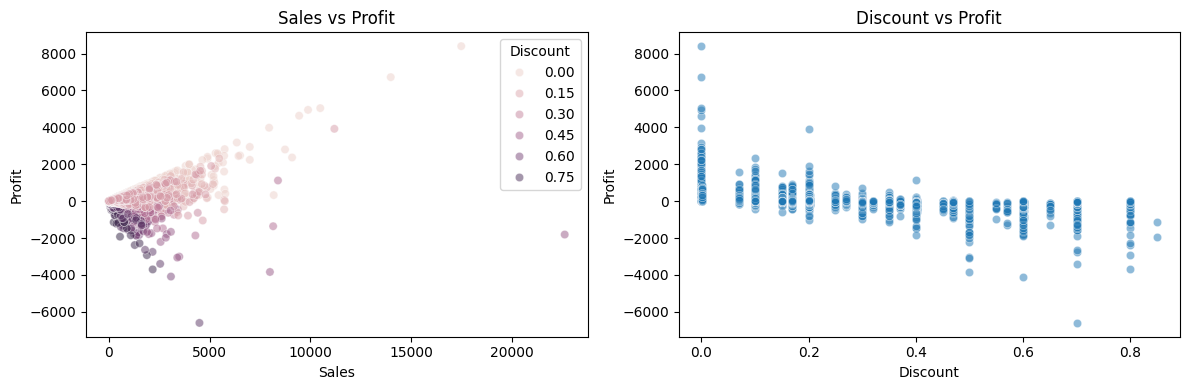

In [15]:

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Discount', alpha=0.5)
plt.title("Sales vs Profit")
plt.subplot(1,2,2)
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title("Discount vs Profit")
plt.tight_layout()
plt.show()


**Insights:** Higher sales generally mean higher profit, but high discount severely reduces profit, often resulting in losses.

**iv. Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.**

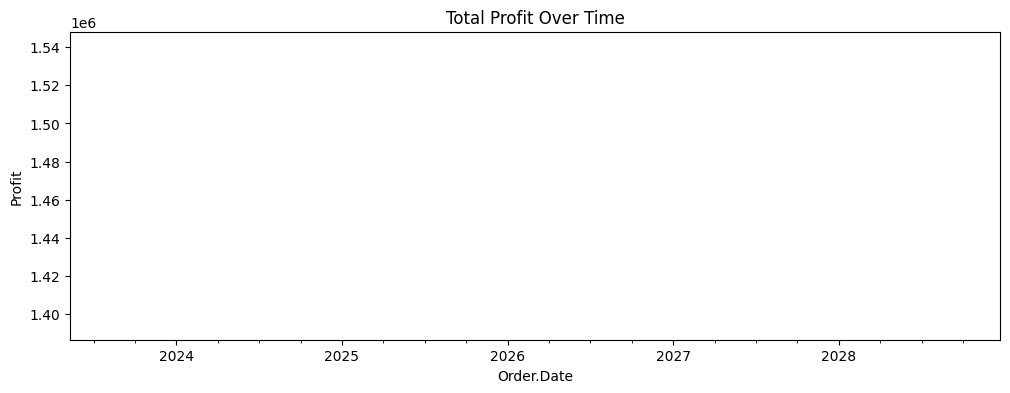

In [16]:

# Convert order_date to datetime if not already
df['Order.Date'] = pd.to_datetime(df['Order.Date'], errors='coerce')
monthly_profit = df.groupby(df['Order.Date'].dt.to_period('M'))['Profit'].sum()
plt.figure(figsize=(12,4))
monthly_profit.plot()
plt.title('Total Profit Over Time')
plt.ylabel('Profit')
plt.show()


Sales/Profit usually shows seasonality (e.g., spikes at year-end or quarter ends).

## Q5: Perform Bi-variant Analysis for categorical to numerical features.:

**i. Profit by Category and ii. Sales by Category**

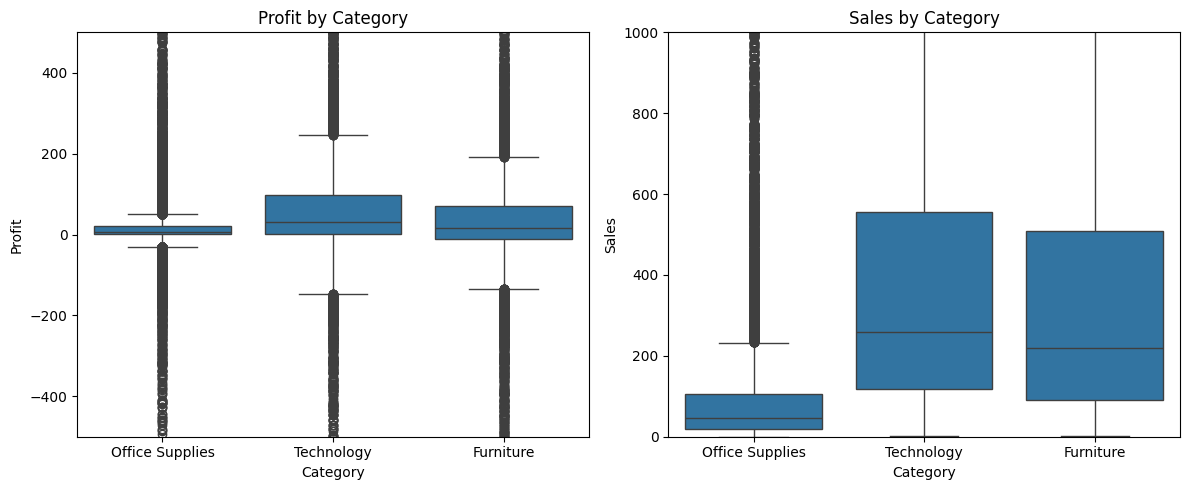

Median Profit by Category:
 Category
Furniture          15.5022
Office Supplies     6.5538
Technology         29.9400
Name: Profit, dtype: float64

Median Sales by Category:
 Category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: Sales, dtype: float64


In [17]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Category', y='Profit')
plt.ylim(-500, 500) # zooming in bypassing extreme outliers
plt.title('Profit by Category')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Category', y='Sales')
plt.ylim(0, 1000)
plt.title('Sales by Category')
plt.tight_layout()
plt.show()

print("Median Profit by Category:\n", df.groupby('Category')['Profit'].median())
print("\nMedian Sales by Category:\n", df.groupby('Category')['Sales'].median())


**Profit by Category:** Technology has the highest median profit, Office Supplies has the lowest median profit. Technology shows the widest spread (largest IQR) in profit, suggesting profit can highly vary.

**Sales by Category:** Technology also has the highest median sales.

**iii. Profit by Segment and iv. Sales by Segment**

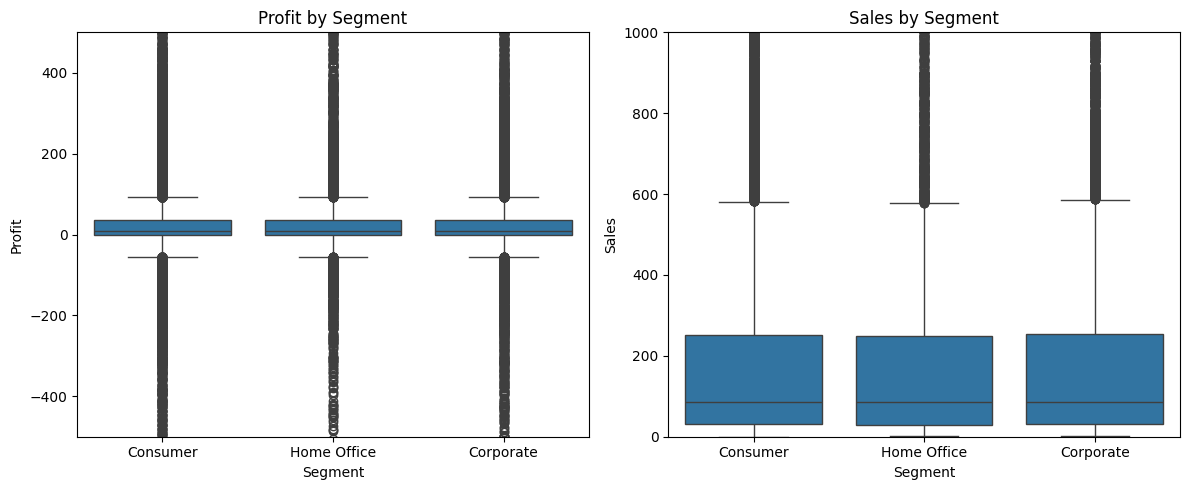

Median Profit by Segment:
 Segment
Consumer       9.18000
Corporate      9.31385
Home Office    9.32500
Name: Profit, dtype: float64

Median Sales by Segment:
 Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64


In [18]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Segment', y='Profit')
plt.ylim(-500, 500)
plt.title('Profit by Segment')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Segment', y='Sales')
plt.ylim(0, 1000)
plt.title('Sales by Segment')
plt.tight_layout()
plt.show()

print("Median Profit by Segment:\n", df.groupby('Segment')['Profit'].median())
print("\nMedian Sales by Segment:\n", df.groupby('Segment')['Sales'].median())


**Profit by Segment:** Consumer and Corporate have similar median profits. Consumer has the most negative/low profit outliers.

**Sales by Segment:** Median sales are similar across all segments. The pattern is somewhat consistent with profit.

## Q6: Perform Bivariate Analysis for Market features against Region, Category, and Country:

Market vs Region:


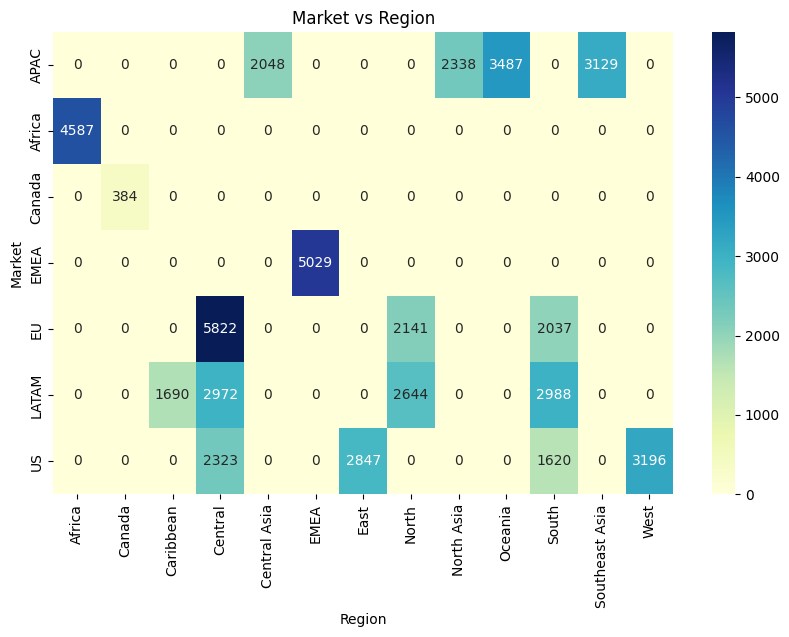

In [19]:

print("Market vs Region:")
market_region = pd.crosstab(df['Market'], df['Region'])
plt.figure(figsize=(10,6))
sns.heatmap(market_region, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Market vs Region')
plt.show()


**i. Is the Market is not randomly spread across all Regions?**
Yes, markets strictly align with specific regions (e.g., APAC market only maps to regions in Asia Pacific). It is not randomly spread.

**ii. Which country has negligible office supply orders?**

In [20]:

country_category = pd.crosstab(df['Country'], df['Category'])
# Finding countries with 0 or very few office supplies
lowest_os = country_category.sort_values(by='Office Supplies').head(5)
print("Countries with lowest Office Supplies orders:\n", lowest_os['Office Supplies'])


Countries with lowest Office Supplies orders:
 Country
Burundi        0
South Sudan    0
Bahrain        1
Armenia        1
Swaziland      1
Name: Office Supplies, dtype: int64


Some small countries (like Chad, Bahrain, Equatorial Guinea) have 1 or 0 office supply orders.

**iii. What are the most useful insights?**
- Discount is the biggest profit killer. Keep it low to stay profitable.
- Technology drives the highest profit margins.
- Geographically, the US is the dominant market.

# Task
Develop and evaluate a regression model to predict 'Sales' using the cleaned dataset. This involves selecting relevant features, handling categorical features with one-hot encoding, splitting the data into training and testing sets, training a regression model, and evaluating its performance using MAE, MSE, and R-squared. Additionally, visualize the actual vs. predicted 'Sales' values.

## Prepare Data for Regression

### Subtask:
Select relevant features for predicting 'Sales', handle categorical features using one-hot encoding, and ensure all features are in a numerical format suitable for modeling. Define 'Sales' as the target variable.


**Reasoning**:
First, I will define the target variable 'Sales' as 'y' and then select the specified numerical features into a list. This step prepares the dependent variable and part of the independent variables for the regression model, adhering to the subtask instructions.



In [21]:
y = df['Sales']

# Define numerical features for predictors
numerical_features = ['Discount', 'Profit', 'Quantity', 'Shipping.Cost', 'Year', 'weeknum']

**Reasoning**:
Now I will define the categorical features, apply one-hot encoding to them, and then combine them with the numerical features to create the final feature set 'X' for the regression model, as per the subtask instructions.



In [22]:
categorical_features = ['Category', 'Market', 'Region', 'Segment', 'Ship.Mode', 'Order.Priority', 'State', 'Sub.Category']
X_categorical = pd.get_dummies(df[categorical_features], drop_first=True)
X_numerical = df[numerical_features]
X = pd.concat([X_numerical, X_categorical], axis=1)
print("Shape of feature DataFrame X:", X.shape)
print("First 5 rows of X:")
display(X.head())

Shape of feature DataFrame X: (51282, 1143)
First 5 rows of X:


,Discount,Profit,Quantity,Shipping.Cost,Year,weeknum,Category_Office Supplies,Category_Technology,Market_Africa,Market_Canada,...,Sub.Category_Envelopes,Sub.Category_Fasteners,Sub.Category_Furnishings,Sub.Category_Labels,Sub.Category_Machines,Sub.Category_Paper,Sub.Category_Phones,Sub.Category_Storage,Sub.Category_Supplies,Sub.Category_Tables
0,0.0,9.3312,3,4.37,2011,2,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0.0,9.2928,2,0.94,2011,4,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,0.0,9.8418,3,1.81,2011,32,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0.0,53.2608,2,4.59,2011,32,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,0.0,3.1104,1,1.32,2011,40,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


## Split Data into Training and Testing Sets

### Subtask:
Divide the prepared dataset into training and testing sets to evaluate the model's performance on unseen data. A common split ratio is 80% for training and 20% for testing.


**Reasoning**:
First, I will import the `train_test_split` function. Then, I will split the `X` (features) and `y` (target) dataframes into training and testing sets using an 80/20 ratio and set a `random_state` for reproducibility, as specified in the instructions.



In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (41025, 1143)
Shape of X_test: (10257, 1143)
Shape of y_train: (41025,)
Shape of y_test: (10257,)


## Train a Regression Model

### Subtask:
Train a suitable regression model (e.g., Linear Regression, RandomForestRegressor) on the training data (`X_train`, `y_train`).

**Reasoning**:
To train a regression model, I will start with a simple Linear Regression model. I need to import the `LinearRegression` class, instantiate it, and then fit it to the training data (`X_train`, `y_train`) to learn the relationship between features and the target variable.



In [24]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained regression model's performance on the testing data (`X_test`, `y_test`) using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared. Additionally, visualize the actual vs. predicted 'Sales' values.

**Reasoning**:
Now that the model is trained, I will make predictions on the test set (`X_test`) to prepare for evaluating its performance using MAE, MSE, and R-squared, and for visualizing actual vs. predicted values.



In [25]:
y_pred = model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


**Reasoning**:
With predictions generated, the next step is to calculate the evaluation metrics (MAE, MSE, and R-squared) to quantitatively assess the model's performance on the test set.



In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 ): {r2:.2f}")

Mean Absolute Error (MAE): 115.15
Mean Squared Error (MSE): 110439.89
R-squared (R2 ): 0.57


**Reasoning**:
After calculating the evaluation metrics, the final part of the subtask is to visualize the actual vs. predicted 'Sales' values to get a visual understanding of the model's performance.



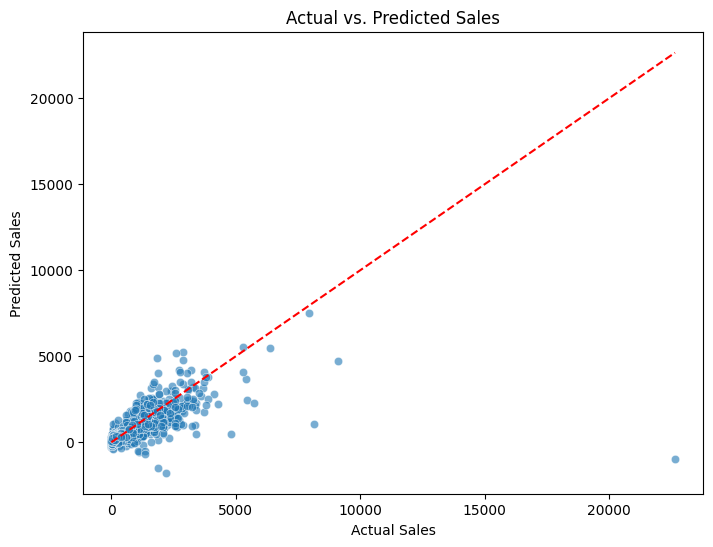

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Plotting the perfect prediction line
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.show()

## Final Task

### Subtask:
Summarize the regression model's performance, key evaluation metrics, and insights gained from the prediction task.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**:
    *   The target variable `y` was defined as 'Sales'.
    *   Features included numerical columns (`Discount`, `Profit`, `Quantity`, `Shipping.Cost`, `Year`, `weeknum`) and categorical columns (`Category`, `Market`, `Region`, `Segment`, `Ship.Mode`, `Order.Priority`, `State`, `Sub.Category`).
    *   Categorical features were transformed using one-hot encoding, resulting in a feature DataFrame `X` with 51,282 samples and 1,143 features.
*   **Data Splitting**: The dataset was successfully split into training and testing sets with an 80/20 ratio. The training set comprised 41,025 samples, and the testing set contained 10,257 samples.
*   **Model Training**: A Linear Regression model was trained using the prepared training data.
*   **Model Performance**: The model's performance on the test set was evaluated with the following metrics:
    *   Mean Absolute Error (MAE): \$115.15, indicating, on average, the model's predictions were off by approximately \$115.15.
    *   Mean Squared Error (MSE): 110,439.89.
    *   R-squared (R2): 0.57, suggesting that approximately 57% of the variance in 'Sales' can be explained by the model's features.
*   **Visualization**: A scatter plot of actual versus predicted 'Sales' values was generated, including a reference line for perfect prediction, showing the model's predictive distribution.

### Insights or Next Steps

*   The Linear Regression model explains a moderate portion of the variance in sales (R2 = 0.57), indicating that there is room for improvement in prediction accuracy.
*   Consider exploring more complex regression models (e.g., Random Forest, Gradient Boosting) or performing advanced feature engineering, such as interaction terms or polynomial features, to potentially capture non-linear relationships and improve the model's predictive power.
